## Problem 3: Breast cancer classification with logistic regression and RFE

Dataset: Scikit-learn breast cancer Wisconsin (diagnostic), 569 tumors with 30 numeric features. Target: 0 = malignant, 1 = benign.

Plan: 70/30 stratified split → standardize features (fit on training set only) → recursive feature elimination (RFE) with a logistic regression estimator down to 2 features → train and evaluate a logistic regression on those 2 features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print('Samples, features:', X.shape)
print('Class counts:', dict(zip(data.target_names.tolist(), np.bincount(y).tolist())))

Samples, features: (569, 30)
Class counts: {'malignant': 212, 'benign': 357}


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 70% train / 30% test, stratified so both sets keep the same malignant/benign ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Features have very different scales (e.g. area ~1000 vs smoothness ~0.1), so standardize.
# Fit the scaler on the training set only to avoid leaking test information.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (398, 30)  Test: (171, 30)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Recursive feature elimination: fit, drop the feature with the smallest |coefficient|,
# refit, and repeat until only 2 features remain
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=2, step=1)
rfe.fit(X_train_s, y_train)

best_features = feature_names[rfe.support_]
print('Best two features:', best_features.tolist())

# Ranking: 1 = selected, 2 = last feature eliminated, ..., 29 = first eliminated
ranking = pd.DataFrame({'feature': feature_names, 'RFE rank': rfe.ranking_}).sort_values('RFE rank')
ranking.head(10).reset_index(drop=True)

Best two features: ['worst area', 'worst concave points']


,feature,RFE rank
0,worst concave points,1
1,worst area,1
2,worst radius,2
3,worst texture,3
4,area error,4
5,worst perimeter,5
6,worst smoothness,6
7,mean area,7
8,worst symmetry,8
9,mean concave points,9


In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

X_train_2 = X_train_s[:, rfe.support_]
X_test_2 = X_test_s[:, rfe.support_]

model = LogisticRegression(max_iter=1000)
model.fit(X_train_2, y_train)

y_pred = model.predict(X_test_2)
y_prob = model.predict_proba(X_test_2)[:, 1]

metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision (benign)': precision_score(y_test, y_pred),
    'Recall (benign)': recall_score(y_test, y_pred),
    'F1 (benign)': f1_score(y_test, y_pred),
    'Precision (malignant)': precision_score(y_test, y_pred, pos_label=0),
    'Recall / sensitivity (malignant)': recall_score(y_test, y_pred, pos_label=0),
    'F1 (malignant)': f1_score(y_test, y_pred, pos_label=0),
    'ROC AUC': roc_auc_score(y_test, y_prob),
}).round(4)
print(metrics.to_string())
print()
print(classification_report(y_test, y_pred, target_names=data.target_names, digits=3))

Accuracy                            0.9415
Precision (benign)                  0.9450
Recall (benign)                     0.9626
F1 (benign)                         0.9537
Precision (malignant)               0.9355
Recall / sensitivity (malignant)    0.9062
F1 (malignant)                      0.9206
ROC AUC                             0.9777

              precision    recall  f1-score   support

   malignant      0.935     0.906     0.921        64
      benign      0.945     0.963     0.954       107

    accuracy                          0.942       171
   macro avg      0.940     0.934     0.937       171
weighted avg      0.941     0.942     0.941       171



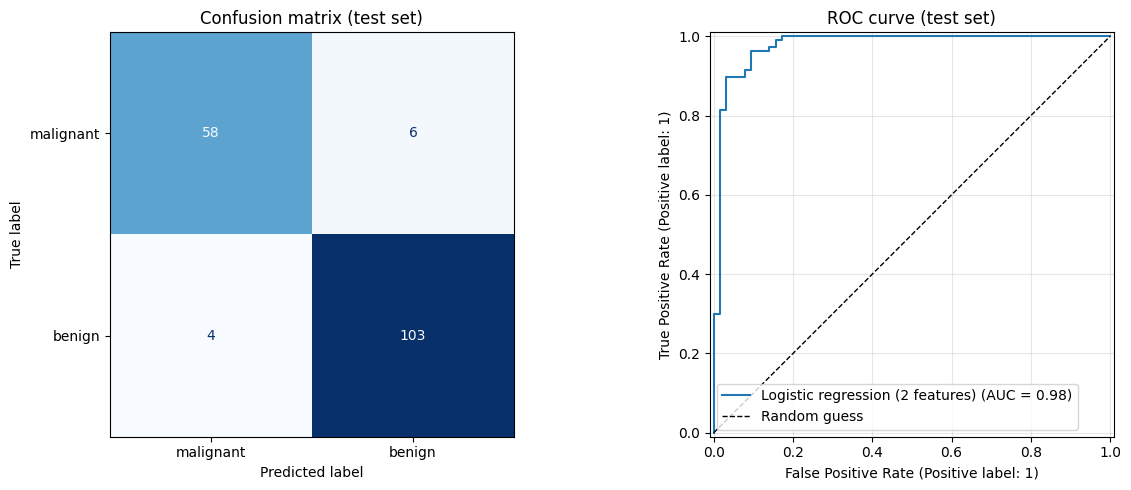

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=data.target_names).plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion matrix (test set)')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax2, name='Logistic regression (2 features)')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
ax2.set_title('ROC curve (test set)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

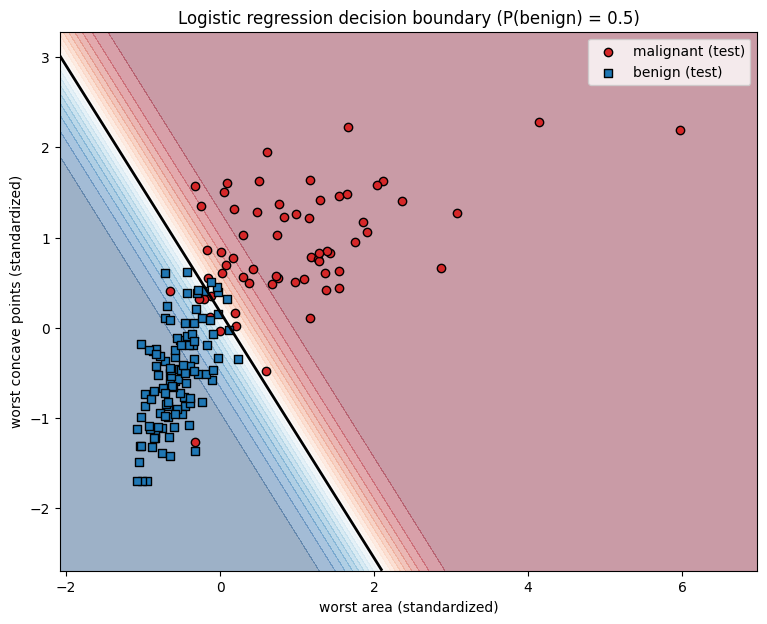

In [6]:
# Decision boundary in the 2 selected (standardized) features
x_min, x_max = X_test_2[:, 0].min() - 1, X_test_2[:, 0].max() + 1
y_min, y_max = X_test_2[:, 1].min() - 1, X_test_2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
zz = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=20, cmap='RdBu', alpha=0.4)
plt.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=2)
for label, color, marker in [(0, '#d62728', 'o'), (1, '#1f77b4', 's')]:
    pts = X_test_2[y_test == label]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, edgecolor='k',
                label=f'{data.target_names[label]} (test)')
plt.xlabel(f'{best_features[0]} (standardized)')
plt.ylabel(f'{best_features[1]} (standardized)')
plt.title('Logistic regression decision boundary (P(benign) = 0.5)')
plt.legend()
plt.show()

In [7]:
# Reference: same model trained on all 30 features, to see what is lost by keeping only 2
model_all = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
y_pred_all = model_all.predict(X_test_s)
y_prob_all = model_all.predict_proba(X_test_s)[:, 1]

comparison = pd.DataFrame({
    '2 features (RFE)': [accuracy_score(y_test, y_pred), recall_score(y_test, y_pred, pos_label=0),
                         f1_score(y_test, y_pred), roc_auc_score(y_test, y_prob)],
    'All 30 features': [accuracy_score(y_test, y_pred_all), recall_score(y_test, y_pred_all, pos_label=0),
                        f1_score(y_test, y_pred_all), roc_auc_score(y_test, y_prob_all)],
}, index=['Accuracy', 'Recall (malignant)', 'F1 (benign)', 'ROC AUC']).round(4)
comparison

,2 features (RFE),All 30 features
Accuracy,0.9415,0.9883
Recall (malignant),0.9062,0.9844
F1 (benign),0.9537,0.9907
ROC AUC,0.9777,0.9981


### Findings

**Selected features.** RFE with logistic regression picked **worst area** and **worst concave points** as the best two features. ("Worst" is the mean of the three largest values in the image.) Both make physical sense: malignant tumors tend to be larger and have more irregular, indented boundaries. The next features to be eliminated were worst radius, worst texture, and area error.

**Test-set performance (171 tumors: 64 malignant, 107 benign) using only 2 features:**

| Metric | Value |
|---|---|
| Accuracy | 0.942 |
| Precision / Recall / F1 (benign) | 0.945 / 0.963 / 0.954 |
| Precision / Recall / F1 (malignant) | 0.935 / 0.906 / 0.921 |
| ROC AUC | 0.978 |

Confusion matrix: 58 of 64 malignant tumors and 103 of 107 benign tumors are classified correctly. There are **6 false negatives** (malignant called benign) and **4 false positives** (benign called malignant).

**Interpretation**
- **Accuracy alone is not enough.** The classes are imbalanced (≈63% benign), and the two kinds of error have very different costs. A missed cancer (false negative) is far worse than an unnecessary follow-up (false positive). So **recall on the malignant class (sensitivity) is the most important metric** here. At 0.906, about 1 in 11 malignant tumors would be missed at the default 0.5 threshold.
- **ROC AUC = 0.978** shows the two features separate the classes very well across all thresholds. Lowering the decision threshold for "benign" would raise malignant recall at the cost of a few more false positives, which is the right trade-off in a medical screening setting.
- The decision-boundary plot shows the two classes are almost linearly separable in this 2-D space. The errors are tumors near the boundary with intermediate size and concavity.
- **Two features versus all thirty:** the full 30-feature model reaches 0.988 accuracy, 0.984 malignant recall, and 0.998 AUC (1 false negative, 1 false positive). Two features keep most of the predictive power (94% vs 99% accuracy) while being much simpler and easier to interpret. For a clinical tool, though, the extra features meaningfully reduce missed cancers (6 → 1).